In [1]:
##  1.Prepare origianl data and synthetic data 

import os
import pandas as pd


os.chdir('/home/jwkim/ADR/')

data = pd.read_csv("./example/data/adult.csv")
syn_data = pd.read_csv("./example/data/syn_adult.csv")

In [2]:
# 2. Discretize the numerical variable and define key and target variables

data["AGE_GROUP"] = data["age"] // 10
syn_data["AGE_GROUP"] = syn_data["age"] // 10

key = ["AGE_GROUP", "sex", "marital-status"]
target = "income"

In [3]:
# 3. Calculate ADR scores and key-level results

from ADR_Measure import ADR_Measure

ADR = ADR_Measure(
    data=data, 
    syn_data=syn_data, 
    key=key, 
    target=target,
    risk_measure="prediction_accuracy", 
    weight="negentropy_concentration" , 
    return_score_df = True
)

adr_oo, adr_os, score_df = ADR.calculate()

print(f"ADR Score (Original vs. Original): {adr_oo:.4f}")
print(f"ADR Score (Original vs. Synthetic): {adr_os:.4f}")
score_df

ADR Score (Original vs. Original): 0.9586
ADR Score (Original vs. Synthetic): 0.5463


,key,risk_measure,weight,score
0,1|Female|Divorced,0.0,0.015222,0.000000
1,1|Female|Married-AF-spouse,0.0,0.015222,0.000000
2,1|Female|Married-civ-spouse,0.0,0.008923,0.000000
3,1|Female|Married-spouse-absent,0.0,0.015222,0.000000
4,1|Female|Never-married,1.0,0.015222,0.015222
...,...,...,...,...
103,9|Female|Separated,0.0,0.015222,0.000000
104,9|Female|Widowed,1.0,0.015222,0.015222
105,9|Male|Married-civ-spouse,0.0,0.002247,0.000000
106,9|Male|Never-married,0.0,0.007561,0.000000


In [4]:
# 4. Summarize overall ADR scores and key-level contribution statistics

import key_level_diagnostics as kld

summary = kld.get_contribution_summary(
    adr_oo,
    adr_os,
    score_df
)

summary

{'adr_oo': 0.9586057803516473,
 'adr_os': 0.546281066080653,
 'dadr': -0.4123247142709944,
 'median_contribution': 0.0035227765378613345,
 'q90_contribution': 0.015066509480246012,
 'top10_contribution': 0.16744209023580348,
 'top10_share': 0.30651271045715195}

In [5]:
# 5. Identify high-contribution keys based on the specified quantile threshold

screening_df = kld.get_screening_keys(
    score_df,
    quantile=0.90
)

screening_df

,key,risk_measure,weight,score
0,1|Female|Never-married,1.0,0.015222,0.015222
1,1|Male|Married-civ-spouse,1.0,0.015222,0.015222
2,2|Male|Widowed,1.0,0.015222,0.015222
3,3|Female|Married-spouse-absent,1.0,0.015222,0.015222
4,5|Female|Separated,1.0,0.015222,0.015222
5,7|Female|Divorced,1.0,0.015222,0.015222
6,7|Female|Separated,1.0,0.015222,0.015222
7,7|Male|Divorced,1.0,0.015222,0.015222
8,8|Female|Widowed,1.0,0.015222,0.015222
9,8|Male|Divorced,1.0,0.015222,0.015222


In [6]:
# 6. Identify the top 10 keys with the highest key-level risk measures

top_risk_df = kld.get_top_risk_keys(
    score_df,
    n=10
)

top_risk_df

,key,risk_measure,weight,score
0,7|Male|Divorced,1.0,0.015222,0.015222
1,5|Female|Separated,1.0,0.015222,0.015222
2,3|Female|Married-spouse-absent,1.0,0.015222,0.015222
3,7|Female|Separated,1.0,0.015222,0.015222
4,1|Female|Never-married,1.0,0.015222,0.015222
5,9|Female|Widowed,1.0,0.015222,0.015222
6,7|Female|Divorced,1.0,0.015222,0.015222
7,1|Male|Married-civ-spouse,1.0,0.015222,0.015222
8,8|Female|Widowed,1.0,0.015222,0.015222
9,2|Male|Widowed,1.0,0.015222,0.015222


In [7]:
# 7. Identify the top 10 keys with the highest ADR contributions

top_contribution_df = kld.get_top_contribution_keys(
    score_df,
    n=10
)

top_contribution_df

,key,risk_measure,weight,score
0,7|Male|Divorced,1.0,0.015222,0.015222
1,5|Female|Separated,1.0,0.015222,0.015222
2,3|Female|Married-spouse-absent,1.0,0.015222,0.015222
3,7|Female|Separated,1.0,0.015222,0.015222
4,1|Female|Never-married,1.0,0.015222,0.015222
5,9|Female|Widowed,1.0,0.015222,0.015222
6,7|Female|Divorced,1.0,0.015222,0.015222
7,1|Male|Married-civ-spouse,1.0,0.015222,0.015222
8,8|Female|Widowed,1.0,0.015222,0.015222
9,2|Male|Widowed,1.0,0.015222,0.015222


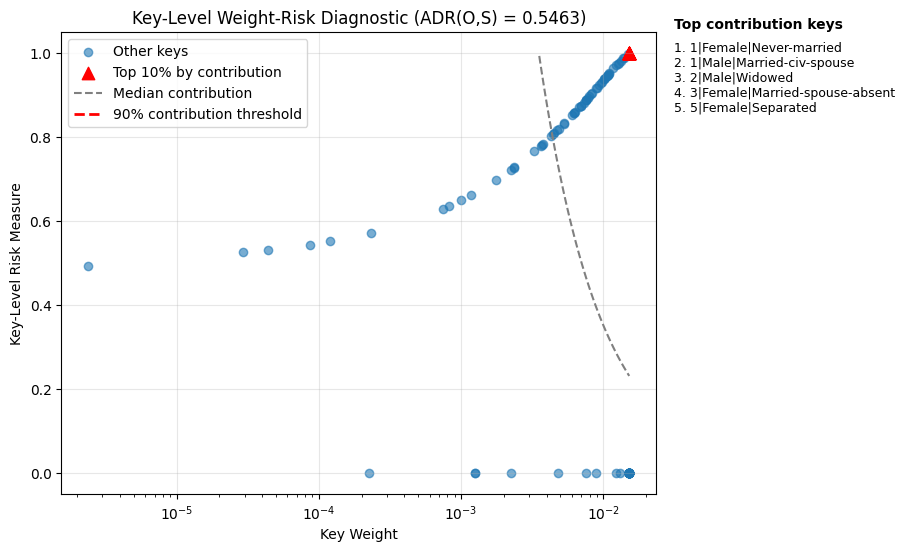

In [8]:
# 8. Visualize the relationship between key-level weights and risk measures

kld.plot_weight_risk(
    score_df,
    adr_os,
    log_scale=True,
    n_labels=5
)